In [12]:
import os
import sys
import json
import time
import argparse
import random
import glob
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from transformers import AutoTokenizer, AutoConfig
from safetensors.torch import load_file
import pyfaidx
import dotenv
from pathlib import Path
import re

# 导入自定义模块（需确保 src 目录在 Python 路径中）
from src.dataset import MultiTrackDataset, load_fasta_sequence
from src.viewer import DatasetViewer, ResultsViewer
from src.model import GenOmics, load_finetuned_model

# 设置中文字体（根据系统环境调整）
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [13]:
class MultiTrackPredictor:
    def __init__(self, fasta_path: str, base_model_path: str, sft_ckpt_path: str,
                 tokenizer_path: str, use_flash_attn: bool,
                 index_stat_path: str = None, index_stat: dict = None,
                 **kwargs):
        self.fasta = pyfaidx.Fasta(fasta_path)
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
        
        # 支持直接传 dict 或从 JSON 文件读取
        if index_stat is not None:
            stat_data = index_stat
        elif index_stat_path is not None:
            stat_data = json.load(open(index_stat_path, "r"))
        else:
            raise ValueError("必须提供 index_stat（dict）或 index_stat_path（文件路径）")
        
        self.model = load_finetuned_model(
            model_class = GenOmics,
            model_path = base_model_path,
            ckpt_path = sft_ckpt_path,
            use_flash_attn = use_flash_attn,
            device = "cuda:0",
            model_init_kwargs={"index_stat": stat_data, **kwargs}
        )
        print("✔️ Model loaded successfully")
        print(self.model)
        self.model.eval()

    def predict(self, chrom: str, start: int, end: int, biosample_names: list = None) -> dict:
            predict_sequence = load_fasta_sequence(self.fasta, chrom, start, end)
            inputs = self.tokenizer(
                predict_sequence,
                return_tensors="pt",
                padding=False,
                truncation=True,
                max_length=32768,
                add_special_tokens=False
            ).to("cuda")
            with torch.no_grad():
                start_time = time.time()
                result = self.model.predict(inputs['input_ids'],
                                            biosample_names=biosample_names)
                time_taken = time.time() - start_time
                torch.cuda.empty_cache()
            print(f"Inference time: {time_taken:.2f} s.")
            return {
                'sequence': predict_sequence,
                'position': (chrom, start, end),
                'values': result
            }
    def predict2(self, chrom: str, start: int, end: int, seq: str, biosample_names: list = None) -> dict:
        sequence = pyfaidx.Fasta(seq)
        predict_sequence = str(sequence[0][:])
        inputs = self.tokenizer(
            predict_sequence,
            return_tensors="pt",
            padding=False,
            truncation=True,
            max_length=32768,
            add_special_tokens=False
        ).to("cuda")
        with torch.no_grad():
            start_time = time.time()
            result = self.model.predict(inputs['input_ids'],
                                        biosample_names = biosample_names)
            time_taken = time.time() - start_time
            torch.cuda.empty_cache()
        print(f"Inference time: {time_taken:.2f} s.")
        return {
            'sequence': predict_sequence,
            'position': (chrom, start, end),
            'values': result
        }

In [14]:
class Args:
    pass

args = Args()
args.mut_fasta = '/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/riceNavi_output/mutant_fastas/example_214.alt.fa'
args.pattern = '*.alt.fa'
args.output_dir = './mutant'
args.save_plots = True
args.plot_tracks = True
args.smoothing_sigma = 10
args.biosample_names = "NIP_leaf"

base_model_dir = "/mnt/rice/default/Workspace/xz/hf/rice_1B_stage2_8k_hf"
sft_ckpt_path = "/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/output/202604020731/checkpoint-23540/model.safetensors"
fasta_path = "/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/osa1_r7.asm.ch.fa"
ANNOTATION_PATH = "/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/mutant_output_260525/modified_osa1_r7.all_models.gff3"
test_data_dir = "/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/riceNavi_output"
riceNavi_csv = os.path.join(test_data_dir, "riceNavi.txt")
index_stat_path = "/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/index_stat3.json"

In [15]:
# 读取 riceNavi.txt
if not os.path.exists(riceNavi_csv):
    print(f"Error: riceNavi.txt not found at {riceNavi_csv}")
    sys.exit(1)
df_riceNavi = pd.read_csv(riceNavi_csv, sep="\t")

# 设置随机种子
seed = 42
random.seed(seed)
np.random.seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)
print(f"✅ Random seed set to {seed}")

# 初始化预测器
predictor = MultiTrackPredictor(
    fasta_path=fasta_path,
    base_model_path=base_model_dir,
    sft_ckpt_path=sft_ckpt_path,
    tokenizer_path=base_model_dir,
    use_flash_attn=True,
    index_stat_path=index_stat_path,
    # index_stat=index_stat,
    proj_dim=1024,
    num_downsamples=4,
    bottleneck_dim=1536
)

✅ Random seed set to 42


2026-08-12 12:30:15,635 - INFO - ⚠️ 使用 Flash Attention 2 需要 torch.float16 或 torch.bfloat16，已自动设置为 torch.bfloat16


✔️ Model loaded successfully
GenOmics(
  (base): MixtralModel(
    (embed_tokens): Embedding(128, 1024, padding_idx=14)
    (layers): ModuleList(
      (0-11): 12 x MixtralDecoderLayer(
        (self_attn): MixtralAttention(
          (q_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (k_proj): Linear(in_features=1024, out_features=512, bias=False)
          (v_proj): Linear(in_features=1024, out_features=512, bias=False)
          (o_proj): Linear(in_features=1024, out_features=1024, bias=False)
        )
        (block_sparse_moe): MixtralSparseMoeBlock(
          (gate): Linear(in_features=1024, out_features=8, bias=False)
          (experts): ModuleList(
            (0-7): 8 x MixtralBlockSparseTop2MLP(
              (w1): Linear(in_features=1024, out_features=4096, bias=False)
              (w2): Linear(in_features=4096, out_features=1024, bias=False)
              (w3): Linear(in_features=1024, out_features=4096, bias=False)
              (act_fn): SiLUAc

In [16]:
viewer = None
if args.plot_tracks:
    if not os.path.exists(ANNOTATION_PATH):
        print(f"Warning: Annotation file not found at {ANNOTATION_PATH}. Track plots will be skipped.")
        args.plot_tracks = False
    else:
        print("Loading annotation for track visualization...")
        viewer = ResultsViewer(annotation_path=ANNOTATION_PATH)

Loading annotation for track visualization...


2026-08-12 12:30:33,265 - INFO - Loaded annotation: genes=14 chromosomes, transcripts=14 chromosomes


In [17]:
# 创建输出目录
os.makedirs(args.output_dir, exist_ok=True)
output_csv = os.path.join(args.output_dir, "result_riceNavi.csv")

In [18]:
def extract_example_name(mut_fasta_path: str) -> str:
    """从突变 FASTA 文件路径中提取示例名称。
    假设文件名格式为 'example_XXX.alt.fa' 或类似，返回 'example_XXX'。
    """
    basename = Path(mut_fasta_path).stem  # 去掉扩展名，例如 'example_106.alt'
    match = re.search(r'(example_\w+)', basename)
    if match:
        return match.group(1)
    else:
        return basename
example_name = extract_example_name(args.mut_fasta)
example_name

'example_214'

In [19]:
# 获取该示例的信息
row = df_riceNavi[df_riceNavi['Example'] == example_name]
if row.empty:
    print(f"Warning: Example '{example_name}' not found in riceNavi.txt, skipping {mut_fasta_path}")
    # return False

# 就地修正窗口坐标 → 0-based 半开区间 [start, end)
# 与训练序列(32768bp)及 alt 突变文件窗口保持一致
row = row.copy()
row.loc[:, 'window_start'] = int(row['window_start'].values[0]) - 1  # 1-based 起点 → 0-based 起点
row.loc[:, 'window_end']   = int(row['window_end'].values[0])        # 半开区间排他终点（保持原 1-based 终点）

gene_ID = row['MSU_ID'].values[0]
chrom = str(row['Chr'].values[0])
gene_start = int(row['start'].values[0])
gene_end = int(row['end'].values[0])
strand = row['strand'].values[0]
window_start = int(row['window_start'].values[0])
window_end = int(row['window_end'].values[0])
length_diff = int(row['length_diff'].values[0])
regulation = str(row['regulation'].values[0])

print(f"\n{'='*60}")
print(f"Processing {example_name}: {gene_ID} on {chrom}:{gene_start}-{gene_end}")
print(f"{'='*60}")


Processing example_214: LOC_Os09g35980 on Chr9:20731589-20734728


In [20]:
row

,Example,MSU_ID,Chr,start,end,strand,window_start,window_end,length_diff,regulation
213,example_214,LOC_Os09g35980,Chr9,20731589,20734728,-,20716773,20749541,0,up-regulation


In [21]:
# 预测参考序列
print("\n--- Predicting reference sequence ---")
ref_predict = predictor.predict(chrom=chrom, start=window_start, end=window_end,
                                biosample_names=args.biosample_names)

# 预测突变序列
print("\n--- Predicting mutant sequence ---")
mut_predict = predictor.predict2(chrom=chrom, start=window_start, end=window_end,
                                    seq=args.mut_fasta, biosample_names=args.biosample_names)


--- Predicting reference sequence ---


/root/miniconda3/envs/vllm/lib/python3.12/site-packages/transformers/models/mixtral/modeling_mixtral.py:373: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1762103288612/work/aten/src/ATen/Context.cpp:233.)
  freqs = (inv_freq_expanded.float() @ position_ids_expanded.float()).transpose(1, 2)
/root/miniconda3/envs/vllm/lib/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with e

Inference time: 2.42 s.

--- Predicting mutant sequence ---
Inference time: 2.35 s.


In [22]:
print(ref_predict)
print(len(ref_predict['sequence']))
print(ref_predict.keys())
print(ref_predict['values'].keys())
print(mut_predict)
print(len(mut_predict['sequence']))

{'sequence': '...', 'position': ('Chr9', 20716773, 20749541), 'values': {'total_RNA-seq_+': {'NIP_leaf': tensor([[[1.4453],
         [1.7109],
         [1.3438],
         ...,
         [0.0167],
         [0.0483],
         [0.0801]]], device='cuda:0', dtype=torch.bfloat16)}}}
32768
dict_keys(['sequence', 'position', 'values'])
dict_keys(['total_RNA-seq_+'])
{'sequence': '...', 'position': ('Chr9', 20716773, 20749541), 'values': {'total_RNA-seq_+': {'NIP_leaf': tensor([[[1.4141],
         [1.7109],
         [1.3438],
         ...,
         [0.0171],
         [0.0491],
         [0.0820]]], device='cuda:0', dtype=torch.bfloat16)}}}
32768


In [24]:
# # 交换变量，因为输入ref和alt的时候位置有问题
# ref_predict, mut_predict = mut_predict, ref_predict

In [25]:
# 计算基因区域表达量（柱状图用）
gene_relative_start = gene_start - window_start - 1
gene_relative_end = gene_end - window_start
ref_plus = ref_predict['values']['total_RNA-seq_+'][args.biosample_names].float().cpu().numpy().flatten()
mut_plus = mut_predict['values']['total_RNA-seq_+'][args.biosample_names].float().cpu().numpy().flatten()

expression_ref_plus = ref_plus[gene_relative_start:gene_relative_end].sum()
expression_mut_plus = mut_plus[gene_relative_start:gene_relative_end + length_diff].sum()

plus_change = ((expression_mut_plus - expression_ref_plus) / expression_ref_plus) * 100 if expression_ref_plus != 0 else 0

# 打印统计
print(f"Reference: + {expression_ref_plus:.2f}")
print(f"Mutant:    + {expression_mut_plus:.2f}")
print(f"Change:    + {plus_change:+.2f}%")
print(f"Gene relative start: {gene_relative_start}; Gene relative end: {gene_relative_end}")

Reference: + 280.93
Mutant:    + 331.64
Change:    + +18.05%
Gene relative start: 14815; Gene relative end: 17955


Comparison summary for /mnt/rice/default/Workspace/yangdong/rice_reg/rice-mutation/cache/predictions/Chr9_20716773_20749541_RNA-seq_NIP_leaf_result2_1786508769.bw
Length: pred=32768, bw=32768
MAE: 0.0049, RMSE: 0.0204, Max abs diff: 0.2916, Corr: 0.9999


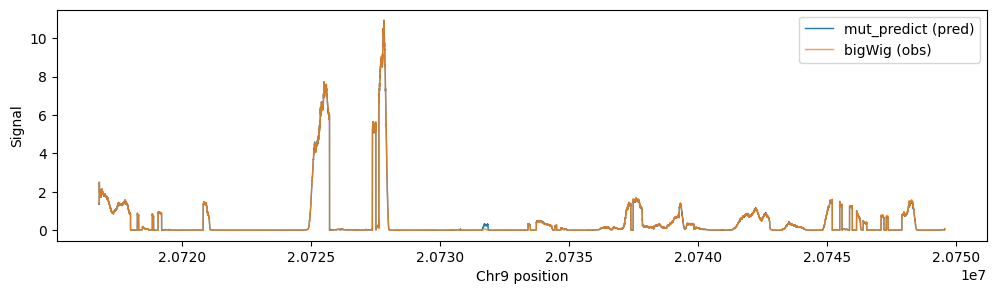

In [26]:
import pyBigWig
import numpy as np
import os

import matplotlib.pyplot as plt

bw_path = "/mnt/rice/default/Workspace/yangdong/rice_reg/rice-mutation/cache/predictions/Chr9_20716773_20749541_RNA-seq_NIP_leaf_result2_1786508769.bw"

if not os.path.exists(bw_path):
    raise FileNotFoundError(f"{bw_path} not found")

# 读取 bigWig 区间值
bw = pyBigWig.open(bw_path)
bw_vals = np.array(bw.values(chrom, window_start, window_end))
bw.close()

# 使用 notebook 中已有的 mut_plus 作为预测突变信号
pred_vals = mut_plus  # numpy array, length should be window_end-window_start

# 对齐长度
n_expected = window_end - window_start
if len(bw_vals) != n_expected:
    print(f"Warning: bigWig length={len(bw_vals)}, expected={n_expected}. Truncating/padding with NaN.")
    if len(bw_vals) > n_expected:
        bw_vals = bw_vals[:n_expected]
    else:
        bw_vals = np.pad(bw_vals, (0, n_expected - len(bw_vals)), constant_values=np.nan)

# 计算差异统计量（忽略 NaN）
mask = ~np.isnan(bw_vals)
common = mask & ~np.isnan(pred_vals)
diff = pred_vals.astype(float) - bw_vals.astype(float)

mae = np.nanmean(np.abs(diff))
rmse = np.sqrt(np.nanmean(diff**2))
max_abs = np.nanmax(np.abs(diff))
corr = np.corrcoef(pred_vals[common], bw_vals[common])[0,1] if np.sum(common) > 1 else np.nan

print(f"Comparison summary for {bw_path}")
print(f"Length: pred={len(pred_vals)}, bw={len(bw_vals)}")
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, Max abs diff: {max_abs:.4f}, Corr: {corr:.4f}")

# 绘图：在 display_start/display_end 区间可视化对比
x = np.arange(window_start, window_end)
if 'display_start' in globals() and 'display_end' in globals():
    viz_mask = (x >= display_start) & (x < display_end)
else:
    viz_mask = slice(None)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(x[viz_mask], pred_vals[viz_mask], label='mut_predict (pred)', lw=1)
ax.plot(x[viz_mask], bw_vals[viz_mask], label='bigWig (obs)', lw=1, alpha=0.8)
ax.set_xlabel(f"{chrom} position")
ax.set_ylabel("Signal")
ax.legend()
plt.show()

Comparison summary for /mnt/rice/default/Workspace/yangdong/rice_reg/rice-mutation/cache/predictions/Chr9_20716773_20749541_RNA-seq_NIP_leaf_result1_1786508769.bw
Length: pred=32768, bw=32768
MAE: 0.0000, RMSE: 0.0000, Max abs diff: 0.0000, Corr: 1.0000


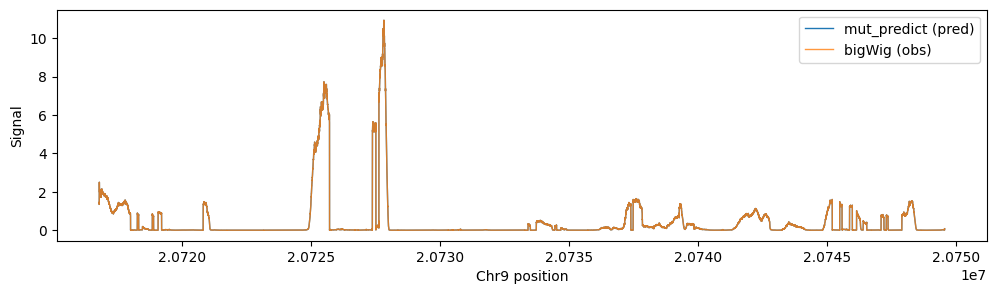

In [27]:
import pyBigWig
import numpy as np
import os

import matplotlib.pyplot as plt

bw_path = "/mnt/rice/default/Workspace/yangdong/rice_reg/rice-mutation/cache/predictions/Chr9_20716773_20749541_RNA-seq_NIP_leaf_result1_1786508769.bw"

if not os.path.exists(bw_path):
    raise FileNotFoundError(f"{bw_path} not found")

# 读取 bigWig 区间值
bw = pyBigWig.open(bw_path)
bw_vals = np.array(bw.values(chrom, window_start, window_end))
bw.close()

# 使用 notebook 中已有的 mut_plus 作为预测突变信号
pred_vals = ref_plus  # numpy array, length should be window_end-window_start

# 对齐长度
n_expected = window_end - window_start
if len(bw_vals) != n_expected:
    print(f"Warning: bigWig length={len(bw_vals)}, expected={n_expected}. Truncating/padding with NaN.")
    if len(bw_vals) > n_expected:
        bw_vals = bw_vals[:n_expected]
    else:
        bw_vals = np.pad(bw_vals, (0, n_expected - len(bw_vals)), constant_values=np.nan)

# 计算差异统计量（忽略 NaN）
mask = ~np.isnan(bw_vals)
common = mask & ~np.isnan(pred_vals)
diff = pred_vals.astype(float) - bw_vals.astype(float)

mae = np.nanmean(np.abs(diff))
rmse = np.sqrt(np.nanmean(diff**2))
max_abs = np.nanmax(np.abs(diff))
corr = np.corrcoef(pred_vals[common], bw_vals[common])[0,1] if np.sum(common) > 1 else np.nan

print(f"Comparison summary for {bw_path}")
print(f"Length: pred={len(pred_vals)}, bw={len(bw_vals)}")
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, Max abs diff: {max_abs:.4f}, Corr: {corr:.4f}")

# 绘图：在 display_start/display_end 区间可视化对比
x = np.arange(window_start, window_end)
if 'display_start' in globals() and 'display_end' in globals():
    viz_mask = (x >= display_start) & (x < display_end)
else:
    viz_mask = slice(None)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(x[viz_mask], pred_vals[viz_mask], label='mut_predict (pred)', lw=1)
ax.plot(x[viz_mask], bw_vals[viz_mask], label='bigWig (obs)', lw=1, alpha=0.8)
ax.set_xlabel(f"{chrom} position")
ax.set_ylabel("Signal")
ax.legend()
plt.show()

In [28]:
print(len(mut_plus), len(ref_plus), length_diff)

32768 32768 0


In [ ]:
# window_start=20716773
# window_end=20749540
# 不再需要硬编码：Cell 8 已通过修正 row 提供正确的 0-based 半开窗口坐标
# （window_start = 20716773, window_end = 20749541，ref 序列长度 = 32768）

In [29]:
ref_predict_modified = {
    'sequence': ref_predict['sequence'],
    'position': ref_predict['position'],
    'values': {
        'total_RNA-seq': ref_predict['values']['total_RNA-seq_+']
    }
}

mut_predict_modified = {
    'sequence': mut_predict['sequence'],
    'position': mut_predict['position'],
    'values': {
        'total_RNA-seq': mut_predict['values']['total_RNA-seq_+']
    }
}

In [ ]:
# !awk '$3=="exon" && /LOC_Os09g35980\.2/' /mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/mutant_output_260525/modified_osa1_r7.all_models.gff3 | awk '{print $4, $5}'

In [ ]:
exon_list = [[20734669,20734728],
[20734435,20734501],
[20733715,20734331],
[20731589,20731844],
[20733400,20733484]]


--- Generating track comparison plot ---


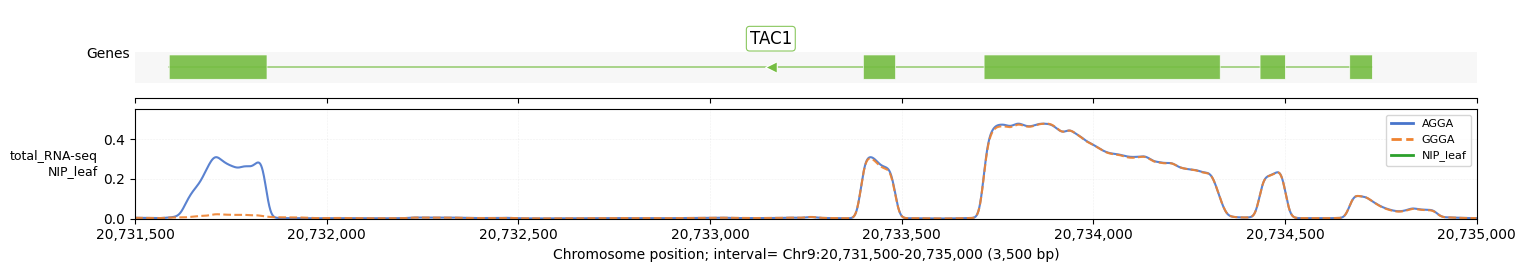

✅ Track comparison plot saved to: ./mutant/example_214_tracks.pdf


In [ ]:
# 导入自定义模块（需确保 src 目录在 Python 路径中）
from src.dataset import MultiTrackDataset, load_fasta_sequence
from src.viewer import DatasetViewer, ResultsViewer
from src.model import GenOmics, load_finetuned_model

# track_window_pad
if args.plot_tracks and viewer is not None:
    print("\n--- Generating track comparison plot ---")
    # 20731500-20735000
    display_start = 20731500
    display_end = 20735000

    fig, axes = viewer.plot3(
        mut_predict_modified, ref_predict_modified,
        smoothing_sigma=args.smoothing_sigma,
        gene_color_minus="#75bd42",
        figsize=(16, 3),
        label_fontsize=12,
        gene_track_height_ratio=0.8,
        window_start=display_start,
        window_end=display_end,
        exclude_legend_labels="NIP_CSQ",
        result2_label="GGGA",
        result1_label="AGGA",
        result2_color="#ef822f",
        result1_color="#4874CB"
    )

    track_plot_path = os.path.join(args.output_dir, f"{example_name}_tracks.pdf")
    plt.show()
    # fig.savefig(track_plot_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✅ Track comparison plot saved to: {track_plot_path}")

U 型连线

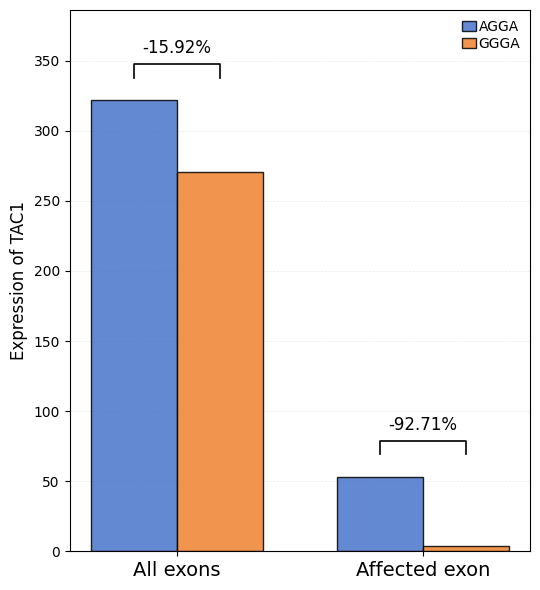

✅ Bar chart saved to: ./mutant/example_214_expression.pdf


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ================= 1. 清晰的数据提取逻辑 =================
# 计算 DER (exon_list[3:4])
expression_ref_der = 0
expression_mut_der = 0
for i in exon_list[3:4]:
    gene_start, gene_end = i[0], i[1]
    gene_relative_start = gene_start - window_start - 1
    gene_relative_end = gene_end - window_start
    expression_ref_der += ref_plus[gene_relative_start:gene_relative_end].sum()
    expression_mut_der += mut_plus[gene_relative_start:gene_relative_end + length_diff].sum()

# 计算 Total (全 exon_list)
# 注意：如果是负链基因，请确保传入的是 ref_minus/mut_minus，此处假设统一用你的信号数组
expression_ref_total = 0
expression_mut_total = 0
for i in exon_list:
    gene_start, gene_end = i[0], i[1]
    gene_relative_start = gene_start - window_start - 1
    gene_relative_end = gene_end - window_start
    expression_ref_total += ref_plus[gene_relative_start:gene_relative_end].sum()
    expression_mut_total += mut_plus[gene_relative_start:gene_relative_end + length_diff].sum()

# ================= 2. 绘图与准确数据绑定 =================
if args.save_plots:
    fig, ax = plt.subplots(figsize=(5.5, 6))
    x = np.arange(2)
    width = 0.35  
    
    # 数组统一按 [Total, DER] 顺序组合
    ref_data = np.array([expression_ref_total, expression_ref_der], dtype=float)  # GGGA
    mut_data = np.array([expression_mut_total, expression_mut_der], dtype=float)  # AGGA

    # 准确计算百分比变化 (GGGA - AGGA) / AGGA * 100
    changes = np.where(ref_data != 0, ((ref_data - mut_data) / mut_data) * 100, 0)

    # 柱体绘制：AGGA在左(x - width/2)，GGGA在右(x + width/2)
    bars_mut = ax.bar(x - width/2, mut_data, width, label='AGGA',
                      color='#4874CB', alpha=0.85, edgecolor='black')
    bars_ref = ax.bar(x + width/2, ref_data, width, label='GGGA',
                      color='#ef822f', alpha=0.85, edgecolor='black')
    
    # # 柱体顶部数值标注
    # for bars in [bars_mut, bars_ref]:
    #     for bar in bars:
    #         height = bar.get_height()
    #         ax.text(bar.get_x() + bar.get_width()/2., height + (height * 0.01), f'{height:.2f}',
    #                 ha='center', va='bottom', fontsize=8, fontweight='bold')
            
    ax.set_ylabel('Expression of TAC1', fontsize=12, fontweight='normal')
    ax.set_xticks(x)
    ax.set_xticklabels(["All exons", "Affected exon"], fontsize=14)
    
    # 动态倒 U 型连线标注
    max_y_total = max(np.max(ref_data), np.max(mut_data))
    bracket_h = max_y_total * 0.03  
    
    for i in range(2):
        x_left = x[i] - width / 2   # AGGA
        x_right = x[i] + width / 2  # GGGA
        
        y_max_pair = max(ref_data[i], mut_data[i])
        y_line = y_max_pair + (max_y_total * 0.05)
        
        # 画倒 U 连线
        ax.plot([x_left, x_left, x_right, x_right], 
                [y_line, y_line + bracket_h, y_line + bracket_h, y_line], 
                lw=1.2, color='black')
        
        # 标注变化百分比
        change_text = f'{changes[i]:+.2f}%'
        ax.text(x[i], y_line + bracket_h + (max_y_total * 0.015), change_text,
                ha='center', va='bottom', fontsize=12, fontweight='normal', color='black')
    
    ax.set_ylim(0, max_y_total * 1.2)
    ax.legend(
        loc='upper right', 
        bbox_to_anchor=(1.0, 1.0), 
        ncol=1, 
        fontsize=10, 
        framealpha=1.0, 
        edgecolor='white',
        labelspacing=0.2,
        columnspacing=0.5,
        handletextpad=0.2,
        handlelength=1.0,
        borderpad=0.2
    )
    ax.grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plot_path = os.path.join(args.output_dir, f"{example_name}_expression.pdf")
    
    # plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    
    print(f"✅ Bar chart saved to: {plot_path}")